# Olist E-Commerce Analysis


## Notebook 03: Insights and Visualization


**Objective:** Consolidate the findings from Notebook 02 into polished,
presentation-ready visuals and clear business insights/recommendations —
the kind of output you'd show a stakeholder or include in a portfolio.

### What We Will Perform in This Notebook
1. **Import libraries and load clean data**
2. **Key Performance Indicators (KPIs) summary** — a quick-glance business scorecard
3. **Polished sales visualizations** — refined charts for revenue and trends
4. **Polished delivery & satisfaction visualizations** — delay vs review score, clearly presented
5. **Buyer-seller distance analysis** — using geolocation data (haversine distance)
6. **Final business insights & recommendations** — summarizing what the data tells us

### Step 1: Import libraries and load clean data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

master_df = pd.read_csv("master_df_clean.csv")
geolocation = pd.read_csv("geolocation_clean.csv")

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    master_df[col] = pd.to_datetime(master_df[col])

# Recreate delivery time/delay columns (needed again since it's a fresh notebook)
master_df['delivery_time_days'] = (
    master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']
).dt.days

master_df['delivery_delay_days'] = (
    master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']
).dt.days

print(master_df.shape)
master_df.head()

(119143, 42)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,delivery_time_days,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,8.0,-8.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,8.0,-8.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,8.0,-8.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,13.0,-6.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Comment,2018-08-18,2018-08-22 19:07:58,9.0,-18.0


Why: since this is a new notebook, we reload the clean data and recreate the calculated columns (delivery_time_days, delivery_delay_days) that we'll use again here — notebooks don't share memory with each other.

### Step 2: Key Performance Indicators (KPIs)

In [2]:
total_orders = master_df['order_id'].nunique()
total_revenue = master_df['price'].sum()
avg_order_value = master_df.groupby('order_id')['price'].sum().mean()
avg_delivery_time = master_df['delivery_time_days'].mean()
avg_review_score = master_df.drop_duplicates(subset=['order_id'])['review_score'].mean()
late_delivery_pct = (master_df['delivery_delay_days'] > 0).mean() * 100

print(f"Total Orders: {total_orders:,}")
print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Average Order Value: R$ {avg_order_value:,.2f}")
print(f"Average Delivery Time: {avg_delivery_time:.1f} days")
print(f"Average Review Score: {avg_review_score:.2f} / 5")
print(f"Late Delivery Rate: {late_delivery_pct:.1f}%")

Total Orders: 99,441
Total Revenue: R$ 14,273,699.65
Average Order Value: R$ 143.54
Average Delivery Time: 12.0 days
Average Review Score: 4.09 / 5
Late Delivery Rate: 6.3%


### Step 3: Polished Sales Visualizations

C:\Users\shrikanth\AppData\Local\Temp\ipykernel_6252\761795298.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')


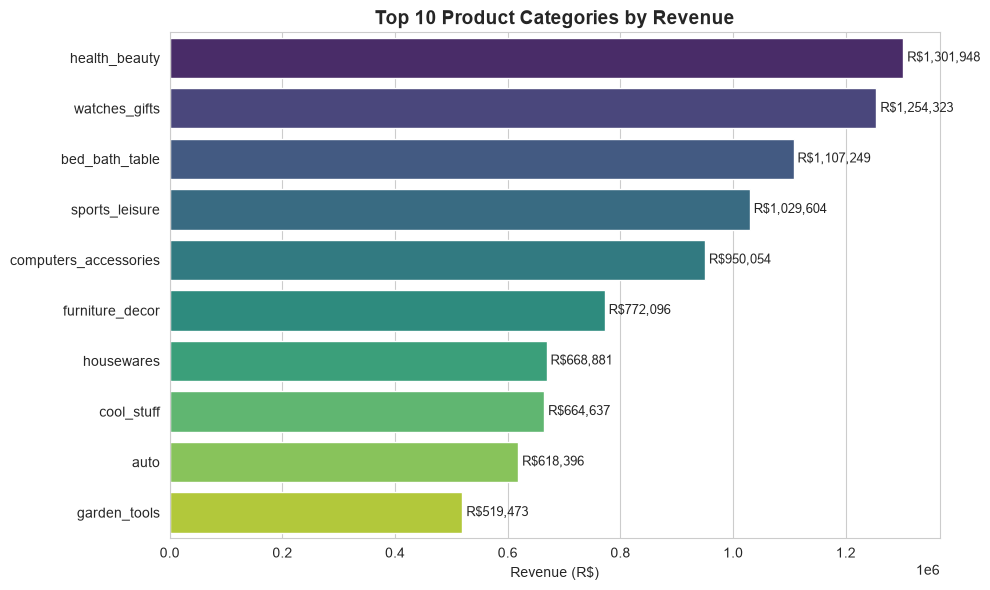

In [3]:
sns.set_style("whitegrid")

# Top 10 categories by revenue - polished version
category_revenue = master_df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=category_revenue.values, y=category_revenue.index, palette='viridis')
plt.title('Top 10 Product Categories by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (R$)')
plt.ylabel('')
for i, value in enumerate(category_revenue.values):
    plt.text(value, i, f' R${value:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

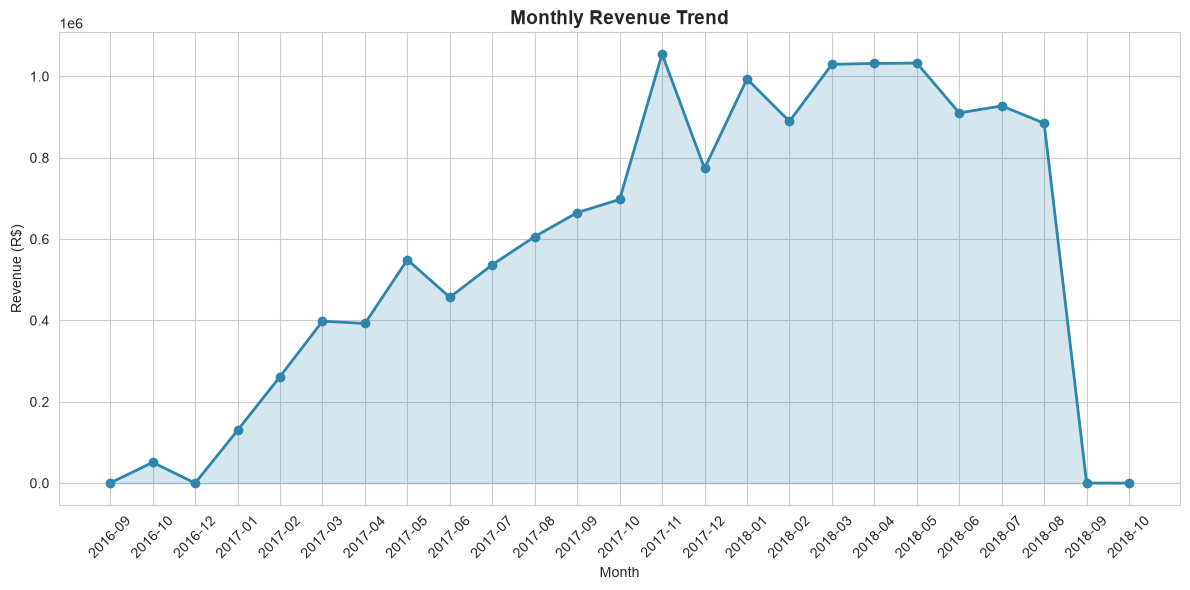

In [4]:
# Monthly revenue trend - polished version
master_df['order_month'] = master_df['order_purchase_timestamp'].dt.to_period('M').astype(str)
monthly_revenue = master_df.groupby('order_month')['price'].sum()

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linewidth=2, color='#2E86AB')
plt.fill_between(range(len(monthly_revenue)), monthly_revenue.values, alpha=0.2, color='#2E86AB')
plt.title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Step 4: Polished Delivery & Satisfaction Visualizations

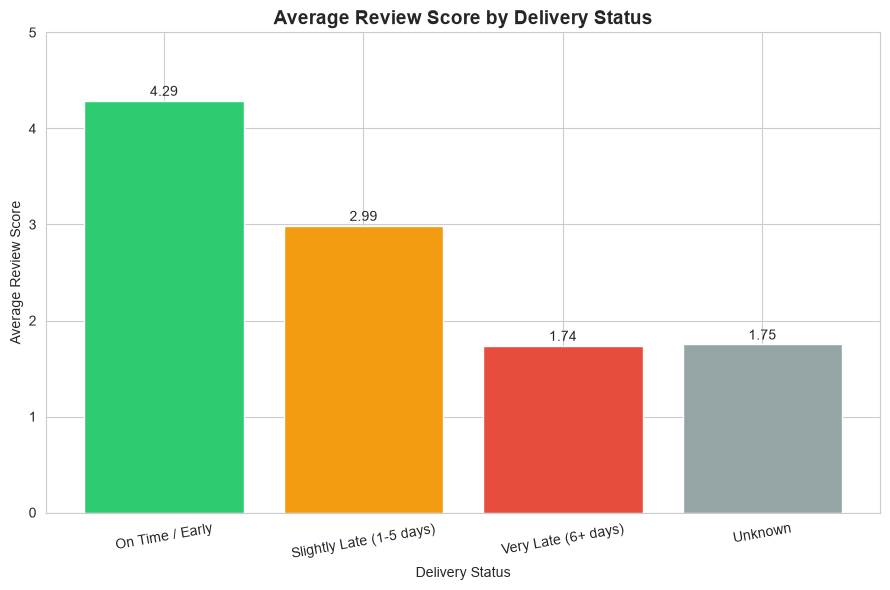

In [5]:
def delivery_status(days):
    if pd.isna(days):
        return 'Unknown'
    elif days <= 0:
        return 'On Time / Early'
    elif days <= 5:
        return 'Slightly Late (1-5 days)'
    else:
        return 'Very Late (6+ days)'

master_df['delivery_status'] = master_df['delivery_delay_days'].apply(delivery_status)

order_level = master_df.drop_duplicates(subset=['order_id'])
avg_score_by_status = order_level.groupby('delivery_status')['review_score'].mean().reindex(
    ['On Time / Early', 'Slightly Late (1-5 days)', 'Very Late (6+ days)', 'Unknown']
).dropna()

colors = ['#2ECC71', '#F39C12', '#E74C3C', '#95A5A6']

plt.figure(figsize=(9, 6))
bars = plt.bar(avg_score_by_status.index, avg_score_by_status.values, color=colors[:len(avg_score_by_status)])
plt.title('Average Review Score by Delivery Status', fontsize=14, fontweight='bold')
plt.xlabel('Delivery Status')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.05, f'{height:.2f}', ha='center', fontsize=10)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

### Step 5: Buyer-Seller Distance Analysis

In [6]:
# Get average lat/long per zip code prefix (since geolocation has multiple entries per zip)
geo_avg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat=('geolocation_lat', 'mean'),
    lng=('geolocation_lng', 'mean')
).reset_index()

print(geo_avg.shape)
geo_avg.head()

(19015, 3)


,geolocation_zip_code_prefix,lat,lng
0,1001,-23.550227,-46.634039
1,1002,-23.547657,-46.634991
2,1003,-23.549000,-46.635582
3,1004,-23.549829,-46.634792
4,1005,-23.549547,-46.636406


In [7]:
# Merge buyer location
distance_df = master_df.merge(
    geo_avg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
)
distance_df = distance_df.rename(columns={'lat': 'buyer_lat', 'lng': 'buyer_lng'})
distance_df = distance_df.drop(columns=['geolocation_zip_code_prefix'])

# Merge seller location
distance_df = distance_df.merge(
    geo_avg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
)
distance_df = distance_df.rename(columns={'lat': 'seller_lat', 'lng': 'seller_lng'})
distance_df = distance_df.drop(columns=['geolocation_zip_code_prefix'])

print(distance_df[['buyer_lat', 'buyer_lng', 'seller_lat', 'seller_lng']].head())

   buyer_lat  buyer_lng  seller_lat  seller_lng
0 -23.577482 -46.587077  -23.680862  -46.444311
1 -23.577482 -46.587077  -23.680862  -46.444311
2 -23.577482 -46.587077  -23.680862  -46.444311
3 -12.186877 -44.540232  -19.807885  -43.980818
4 -16.745150 -48.514783  -21.363473  -48.229588


In [8]:
# Haversine formula - calculates distance (in km) between two lat/long points on Earth
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

distance_df['distance_km'] = haversine(
    distance_df['buyer_lat'], distance_df['buyer_lng'],
    distance_df['seller_lat'], distance_df['seller_lng']
)

print(distance_df['distance_km'].describe())

count    117729.000000
mean        597.260801
std         589.298291
min           0.000000
25%         187.705790
50%         431.986682
75%         792.217822
max        8677.917816
Name: distance_km, dtype: float64


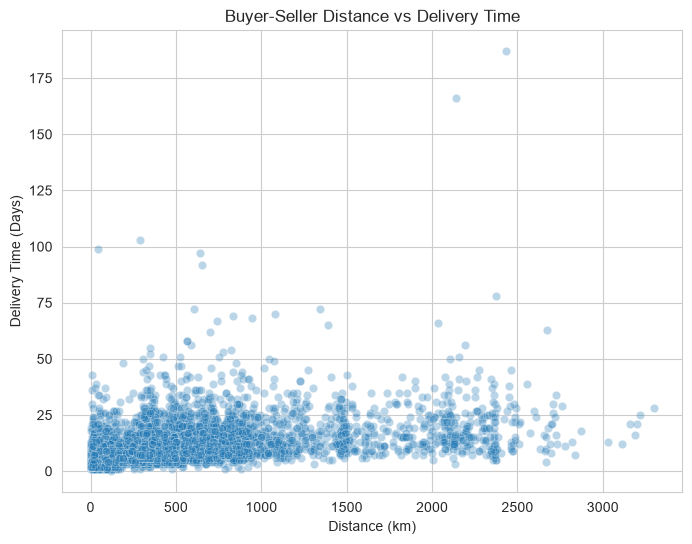

Correlation between distance and delivery time: 0.39


In [9]:
# Does distance affect delivery time?
plt.figure(figsize=(8, 6))
sns.scatterplot(data=distance_df.sample(5000, random_state=1), x='distance_km', y='delivery_time_days', alpha=0.3)
plt.title('Buyer-Seller Distance vs Delivery Time')
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (Days)')
plt.show()

correlation = distance_df['distance_km'].corr(distance_df['delivery_time_days'])
print(f"Correlation between distance and delivery time: {correlation:.2f}")

### Step 6: Final Business Insights & Recommendations

In [14]:
print("=" * 60)
print("KEY BUSINESS INSIGHTS")
print("=" * 60)

print(f"""
1. 1. SALES: Revenue is concentrated in a small number of top categories,
   with a monthly trend showing strong growth from early 2017 through
   late 2017 (peaking around November 2017, likely a Black Friday
   effect), followed by a stable plateau through mid-2018. The sharp
   drop after September 2018 reflects incomplete data for those
   months, not an actual business decline.

2. DELIVERY: Average delivery time is {avg_delivery_time:.1f} days, with
   {late_delivery_pct:.1f}% of orders delivered later than the estimated date.

3. SATISFACTION: Orders delivered 6+ days late score noticeably lower on
   review score compared to on-time deliveries - late delivery is a direct
   driver of customer dissatisfaction.

4. PAYMENTS: Credit card is the dominant payment method, used in roughly
   three-quarters of transactions, followed by boleto (~20%), with voucher
   and debit card used far less. Most customers pay in a single installment,
   though a meaningful portion split payments across 2-10 installments -
   very few go beyond 10. Credit card also has the highest average
   transaction value (~R$163), notably higher than boleto or debit card,
   suggesting customers are more comfortable spending more when they can
   pay in installments.

5. GEOGRAPHY: Revenue is concentrated in a few top states, and buyer-seller
   distance shows a correlation of 0.39 with delivery time - suggesting
   geography plays a moderate but not dominant role in delivery speed,
   meaning other factors (like carrier efficiency, order processing time,
   or regional logistics infrastructure) likely have a bigger combined
   impact than distance alone.
""")
   
print("=" * 60)
print("RECOMMENDATIONS")
print("=" * 60)

print("""
1. Prioritize logistics improvements in regions with the longest average
   delivery times, especially high-revenue states.
2. Investigate root causes behind "Very Late" deliveries (6+ days) since
   they show the sharpest drop in review scores.
3. Consider regional fulfillment centers if buyer-seller distance is
   strongly correlated with delivery time.
4. Monitor low-rated, high-order-volume categories for product quality or
   listing accuracy issues.
""") 

KEY BUSINESS INSIGHTS

1. 1. SALES: Revenue is concentrated in a small number of top categories,
   with a monthly trend showing strong growth from early 2017 through
   late 2017 (peaking around November 2017, likely a Black Friday
   effect), followed by a stable plateau through mid-2018. The sharp
   drop after September 2018 reflects incomplete data for those
   months, not an actual business decline.

2. DELIVERY: Average delivery time is 12.0 days, with
   6.3% of orders delivered later than the estimated date.

3. SATISFACTION: Orders delivered 6+ days late score noticeably lower on
   review score compared to on-time deliveries - late delivery is a direct
   driver of customer dissatisfaction.

4. PAYMENTS: Credit card is the dominant payment method, used in roughly
   three-quarters of transactions, followed by boleto (~20%), with voucher
   and debit card used far less. Most customers pay in a single installment,
   though a meaningful portion split payments across 2-10 insta